# Small EBSD

**Reproducibility note:** Results shown were computed on an A100 GPU. Re-running requires a GPU and significant compute time. Pre-computed outputs are preserved here for reference. Result pkl files (~487 MB) are not included in the repository.

## Polynomial minimisation-diagram fits to a real EBSD grain map

This notebook fits polynomial minimisation diagrams of orders $h_o \in \{1,\ldots,8\}$
to the small EBSD grain map from the Tata Steel dataset. The input data have been
pre-cleaned (`small_ebsd_data_proto.ipynb`): four suspect grains — two genuinely
disconnected and two joined by a thin neck — have been split into geometrically
coherent sub-grains, bringing the total from 241 to 245. Each fit minimises the
multinomial logistic-regression surrogate to the hard pixel assignment by L-BFGS,
with a fixed iteration budget `MAX_ITER` as the only stopping rule. Every base
configuration is run twice: once from a cold start and once from the physical
heuristic initialisation.

In [1]:
import os

# For the GPU rerun: locate CUDA so KeOps can compile its kernels.
# No effect on a CPU-only laptop run.
if os.path.isdir("/opt/conda/targets/x86_64-linux"):
    os.environ["CUDA_HOME"] = "/opt/conda/targets/x86_64-linux"
    os.environ["PATH"] = f"{os.environ['CUDA_HOME']}/bin:" + os.environ["PATH"]
    os.environ["LD_LIBRARY_PATH"] = (
        f"{os.environ['CUDA_HOME']}/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
    )

In [2]:
import math
import time
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import PyAPD

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

device = "cuda" if torch.cuda.is_available() else "cpu"
dt = torch.float64
torch.set_default_dtype(dt)
torch.set_default_device(device)
torch.set_printoptions(precision=10)
torch.set_flush_denormal(True)

True

## Experiment parameters

In [3]:
MAX_ITER = 1000    # L-BFGS iterations — the only stopping rule
EPS      = 1e-2   # design-matrix scale (a reparametrisation of theta)

DATA_DIR   = Path("data")
GRID_SHAPE = (252, 251)

# Seed for sampling grain colours from grains_coloring_tata.txt.
# Changing this only affects visual appearance, not the fits.
COLORING_SEED = 42

## Load data

The cleaned files have the same column layout as the originals:
`orient_grain_clean.dat` has a 1-based grain index followed by three Bunge
Euler angles; `orientation_per_pixel_clean.dat` has three Euler angles
followed by the $(x, y)$ pixel coordinates. Grain assignment is by
closest Euler-angle distance.

In [4]:
orient_grain_raw = np.loadtxt(DATA_DIR / "orient_grain_clean.dat")
orient_pixel_raw = np.loadtxt(DATA_DIR / "orientation_per_pixel_clean.dat")

orient_grain = orient_grain_raw[:, 1:4]   # (N, 3)
orient_pixel = orient_pixel_raw[:, 0:3]   # (M, 3)

diffs  = orient_pixel[:, None, :] - orient_grain[None, :, :]
I_flat = np.argmin(np.sum(diffs * diffs, axis=2), axis=1).astype(np.int64)

N_grains = orient_grain.shape[0]
M_pixels = orient_pixel.shape[0]
print(f"  grains: {N_grains}   pixels: {M_pixels}")

# Y: pixel (x, y) coordinates, rescaled to the unit square.
xy = orient_pixel_raw[:, 3:5]
Y  = torch.tensor(xy, dtype=dt, device=device)
Y  = Y / Y.abs().max(dim=0).values

I = torch.tensor(I_flat, dtype=torch.int32, device=device)
pixel_params = GRID_SHAPE

# Grain colour map: sample N_grains rows from the Tata colour table.
coloring_raw = np.loadtxt(DATA_DIR / "grains_coloring_tata.txt", skiprows=1)  # (4686, 3)
rng_color    = np.random.default_rng(COLORING_SEED)
idx_color    = rng_color.permutation(len(coloring_raw))[:N_grains]
grain_colors = coloring_raw[idx_color]  # (N_grains, 3)
cmap_grains  = ListedColormap(grain_colors)

  grains: 245   pixels: 63252


## Helpers

`run_ebsd_to_mds_fit` fits a polynomial minimisation diagram of order `ho`
to the pre-loaded grain map `(I, Y)` and returns a self-contained dictionary
of **CPU tensors and plain-Python metadata** — no live `min_diagram_system`
object is retained, so the result can be pickled and reloaded on any machine.

`grids_and_error` rasterises the truth, the reconstruction, and the per-pixel
error indicator onto the pixel grid.

In [5]:
def ordinal(n: int) -> str:
    if 10 <= (n % 100) <= 20:
        suf = "th"
    else:
        suf = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suf}"


def run_ebsd_to_mds_fit(
    I,
    Y,
    pixel_params,
    ho,
    eps=EPS,
    max_iter=MAX_ITER,
    heuristic_guess=False,
    verbose=False,
):
    """Fit a polynomial minimisation diagram of order `ho` to `(I, Y)` and
    return a CPU-only dict with arrays, metadata, and timings.
    """
    mds = PyAPD.min_diagram_system(
        Y=Y,
        grain_map=I,
        pixel_params=pixel_params,
        ho=ho,
        eps=eps,
        heuristic_guess=heuristic_guess,
        dt=dt,
        device=device,
    )
    t0 = time.time()
    mds.fit_theta(
        max_iter=max_iter,
        gtol=0.0,
        xtol=0.0,
        backend="auto",
        verbose=verbose,
    )
    fit_time = time.time() - t0
    I_recon = mds.assemble_diagram()

    return {
        "Y":               mds.Y.detach().cpu().clone(),
        "I_truth":         mds.I.detach().cpu().clone(),
        "I_recon":         I_recon.detach().cpu().clone(),
        "theta":           mds.theta.detach().cpu().clone(),
        "pixel_params":    tuple(pixel_params),
        "N":               int(mds.N),
        "ho":              ho,
        "eps":             eps,
        "max_iter":        max_iter,
        "heuristic_guess": heuristic_guess,
        "fit_time":        fit_time,
    }


def grids_and_error(out, cmap_grains):
    """Rasterise truth, reconstruction, and error onto the pixel grid."""
    Y       = out["Y"]
    I_truth = out["I_truth"]
    I_recon = out["I_recon"]
    pp      = out["pixel_params"]
    N       = out["N"]

    domain = torch.stack([Y.min(dim=0).values, Y.max(dim=0).values], dim=1)

    G_truth = PyAPD.gridify_Y_I(Y, I_truth.to(torch.int32), domain, pp)
    G_recon = PyAPD.gridify_Y_I(Y, I_recon.to(torch.int32), domain, pp)
    err_vec = (I_truth != I_recon).to(torch.float32)
    G_err   = PyAPD.gridify_Y_I(Y, err_vec, domain, pp)
    pe      = err_vec.mean().item()

    return G_truth, G_recon, G_err, pe

## Experimental configurations

Eight base configurations, one per polynomial degree $h_o = 1, \ldots, 8$.
Each is run twice: once from a zero initialisation (cold start) and once from
the physical heuristic based on grain moments, giving 16 configurations in total.
Tags are doubled for the heuristic variants: AA, BB, ..., HH.

| tag | $h_o$ | $K$ |
|:---:|:-----:|:---:|
| A   | 1     | 3   |
| B   | 2     | 6   |
| C   | 3     | 10  |
| D   | 4     | 15  |
| E   | 5     | 21  |
| F   | 6     | 28  |
| G   | 7     | 36  |
| H   | 8     | 45  |

In [6]:
letters = "ABCDEFGH"
spec = [
    dict(tag=letters[i], ho=i + 1)
    for i in range(len(letters))
]

configs = (
    [{**s, "heuristic_guess": False} for s in spec]
    + [{**s, "tag": s["tag"] * 2, "heuristic_guess": True} for s in spec]
)

print(f"{len(configs)} configurations: {[c['tag'] for c in configs]}")
for cfg in configs[:len(letters)]:
    K        = math.comb(2 + cfg["ho"], cfg["ho"])
    compress = N_grains * K / (M_pixels + 2 * M_pixels)
    print(f"  {cfg['tag']}  ho={cfg['ho']}  K={K:3d}  "
          f"total params={N_grains * K:6d}  compress={compress:.4f}")

16 configurations: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'AA', 'BB', 'CC', 'DD', 'EE', 'FF', 'GG', 'HH']
  A  ho=1  K=  3  total params=   735  compress=0.0039
  B  ho=2  K=  6  total params=  1470  compress=0.0077
  C  ho=3  K= 10  total params=  2450  compress=0.0129
  D  ho=4  K= 15  total params=  3675  compress=0.0194
  E  ho=5  K= 21  total params=  5145  compress=0.0271
  F  ho=6  K= 28  total params=  6860  compress=0.0362
  G  ho=7  K= 36  total params=  8820  compress=0.0465
  H  ho=8  K= 45  total params= 11025  compress=0.0581


## Run the sweep

Each configuration fits `MAX_ITER` L-BFGS iterations to the same `(I, Y)`
and packs a CPU-only result dictionary.

In [7]:
outs = []
for cfg in configs:
    print(f"[{cfg['tag']}] ho={cfg['ho']}  heuristic={cfg['heuristic_guess']}")
    out = run_ebsd_to_mds_fit(
        grain_map=I,
        Y=Y,
        pixel_params=pixel_params,
        ho=cfg["ho"],
        heuristic_guess=cfg["heuristic_guess"],
    )
    outs.append(out)
    _, _, _, pe = grids_and_error(out, cmap_grains)
    print(f"         fit={out['fit_time']:6.2f}s  pixel err={100*pe:.3f}%")

[A] ho=1  heuristic=False
Optimality condition successfully overwritten.
         fit= 25.94s  pixel err=8.545%
[B] ho=2  heuristic=False
Optimality condition successfully overwritten.
         fit= 28.50s  pixel err=3.945%
[C] ho=3  heuristic=False
Optimality condition successfully overwritten.
OKeOps] Generating code for Max_SumShiftExpWeight_Reduction reduction (with parameters 1) of formula [a|b,1] with a=Var(0,10,0), b=Var(1,10,1) ... 
[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula (Extract(c,1,1)*b)*Exp(a|b-Extract(d,0,1)) with a=Var(0,10,0), b=Var(1,10,1), c=Var(2,2,1), d=Var(3,2,1) ... OK
[KeOps] Generating code for ArgMin_Reduction reduction (with parameters 1) of formula Sum(-(a*b)) with a=Var(0,10,0), b=Var(1,10,1) ... OK
         fit= 33.59s  pixel err=2.909%
[D] ho=4  heuristic=False
Optimality condition successfully overwritten.
OKeOps] Generating code for Max_SumShiftExpWeight_Reduction reduction (with parameters 1) of formula [a|b,1] 

## Visualisation

For each configuration we produce a $1 \times 3$ figure: the EBSD truth,
the polynomial minimisation-diagram reconstruction, and the per-pixel error
indicator. Figures are saved to `figures/ebsd_{j}.pdf`.

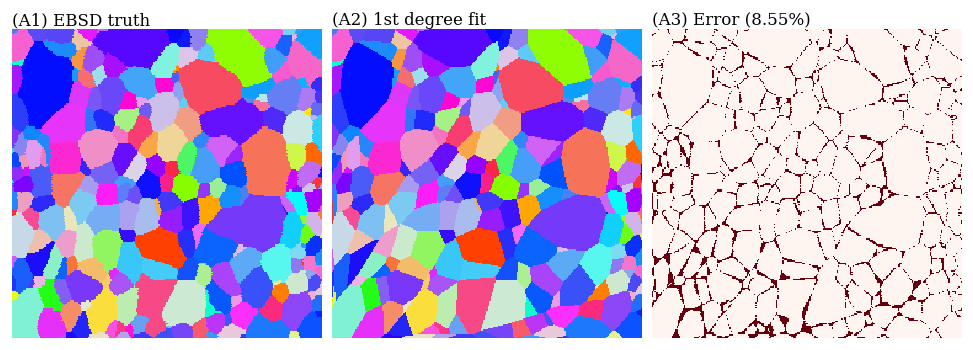

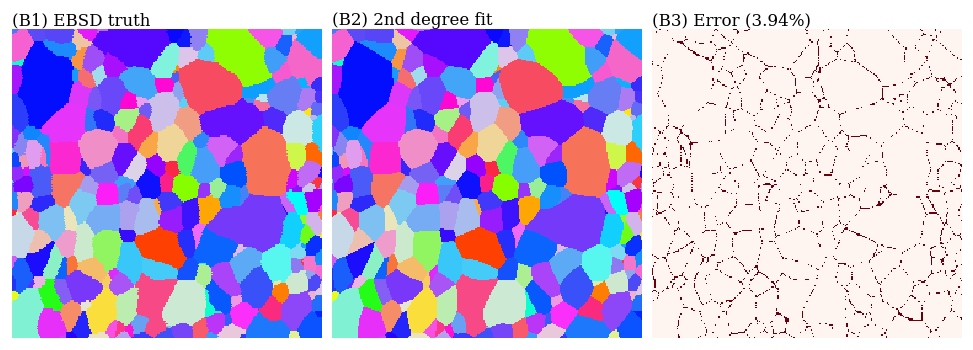

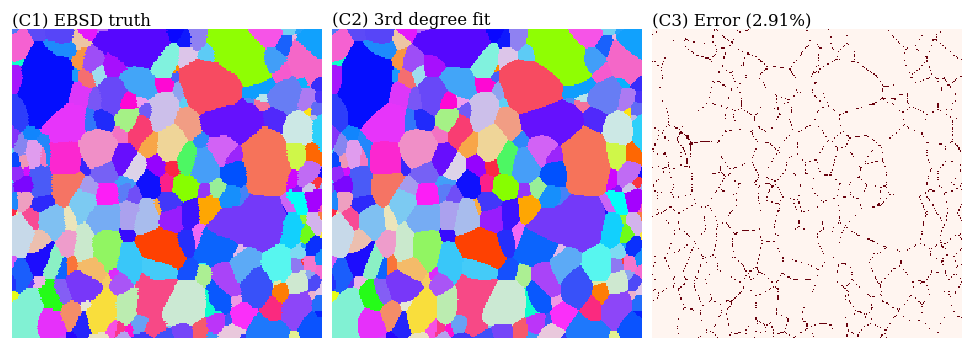

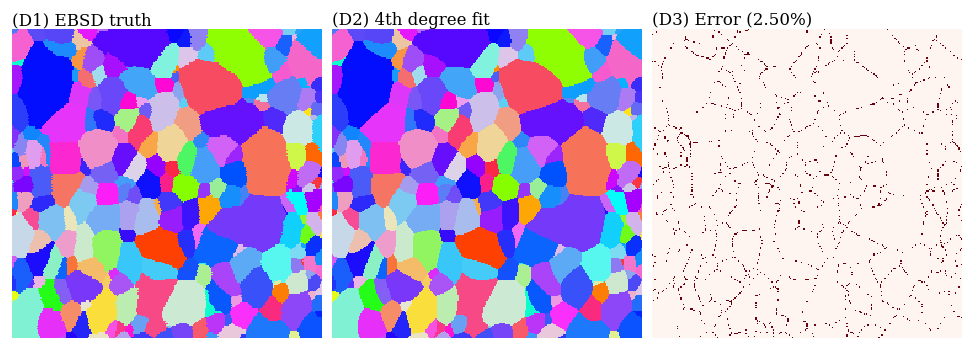

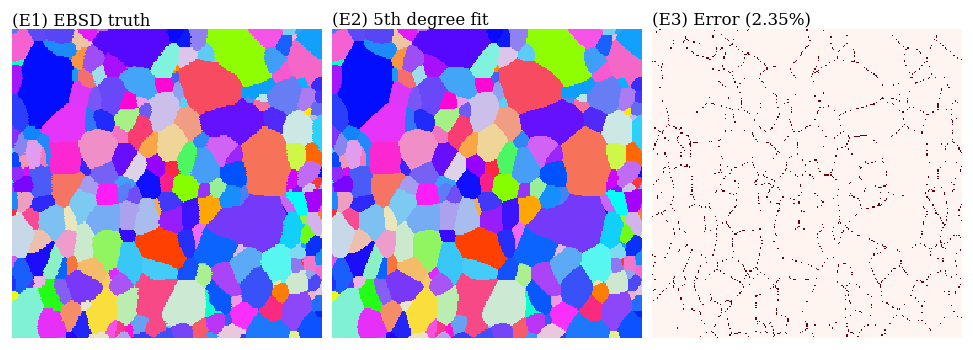

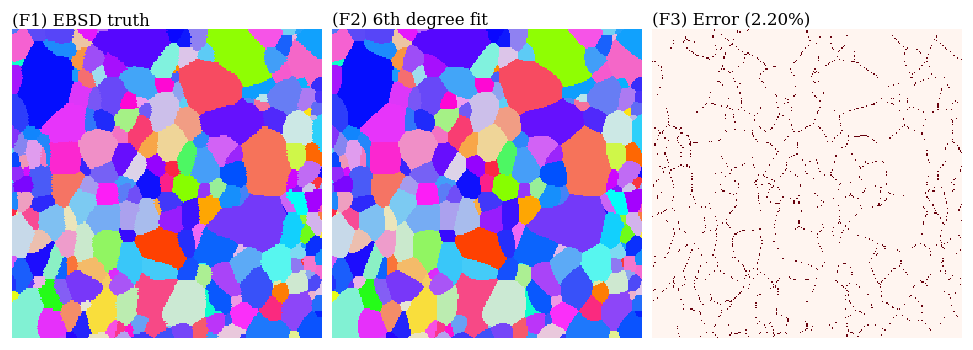

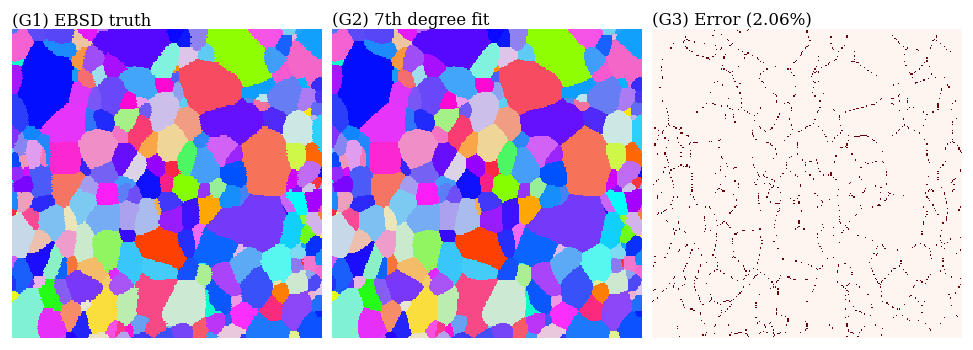

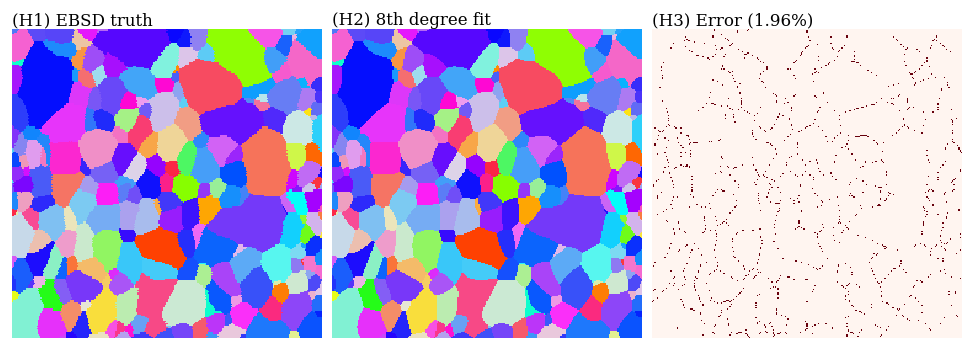

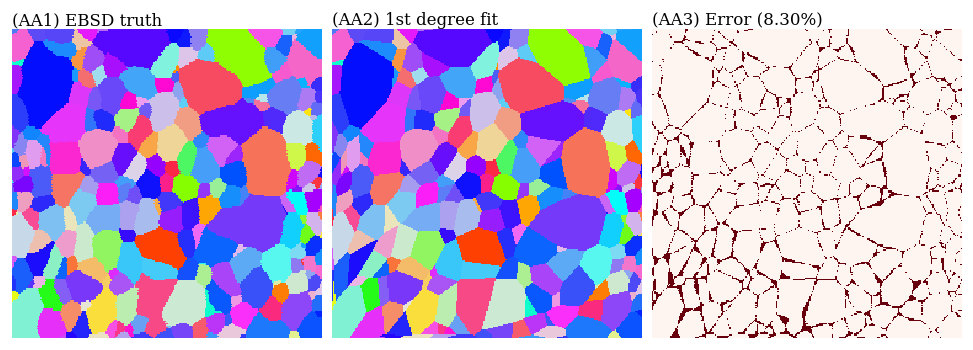

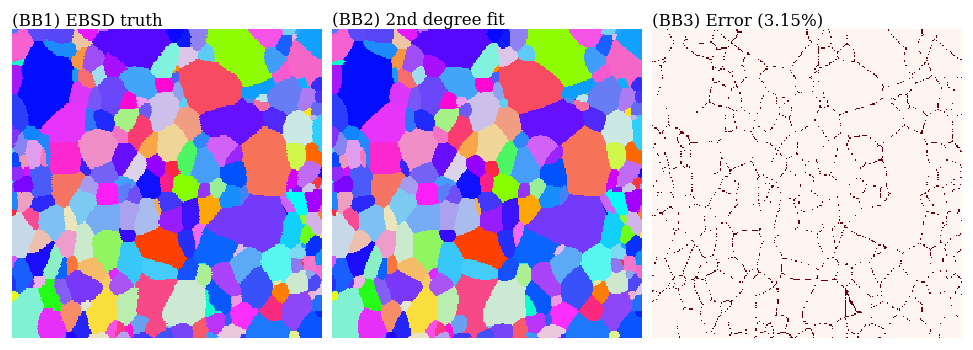

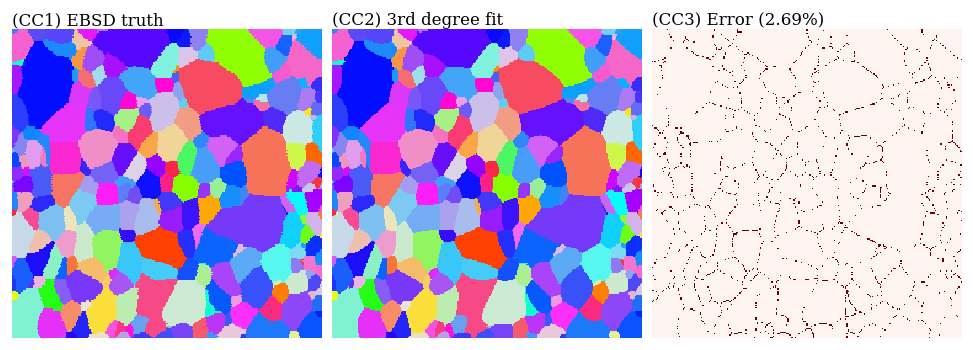

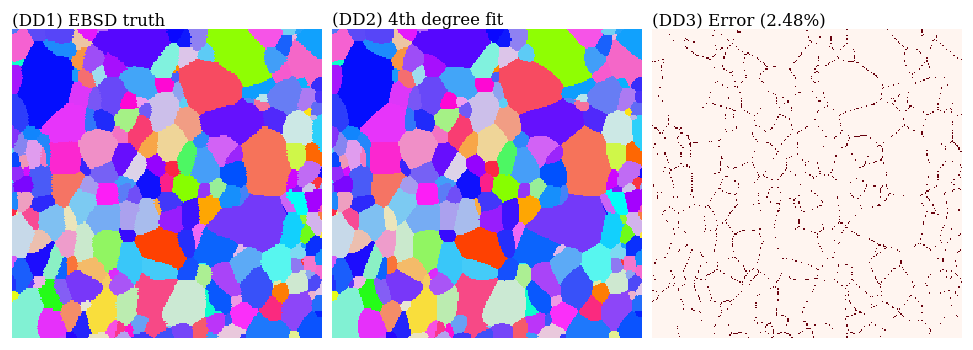

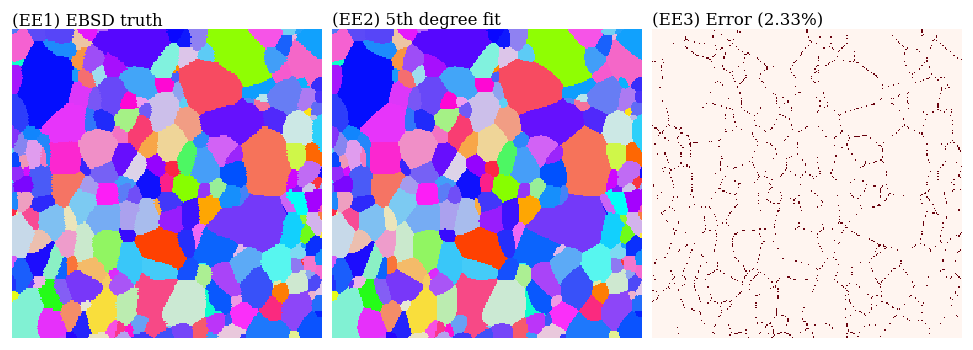

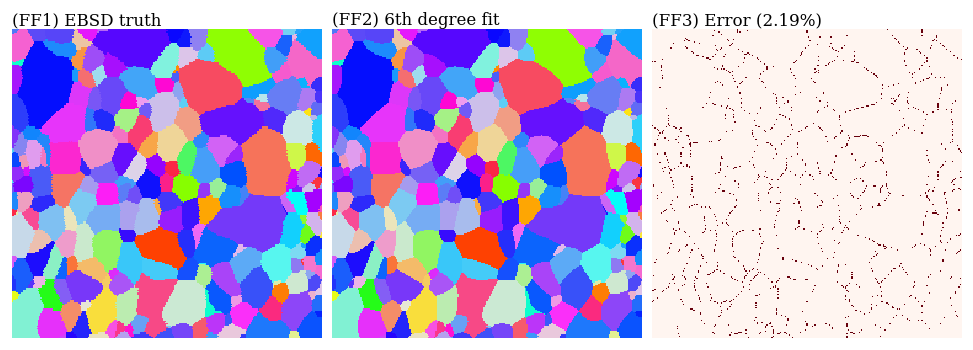

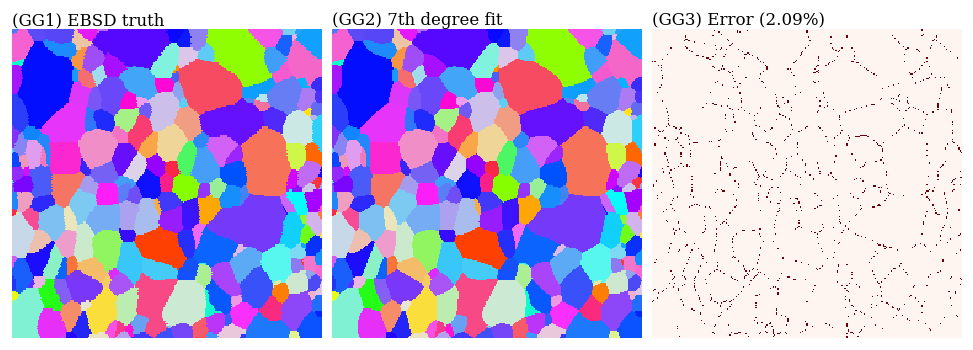

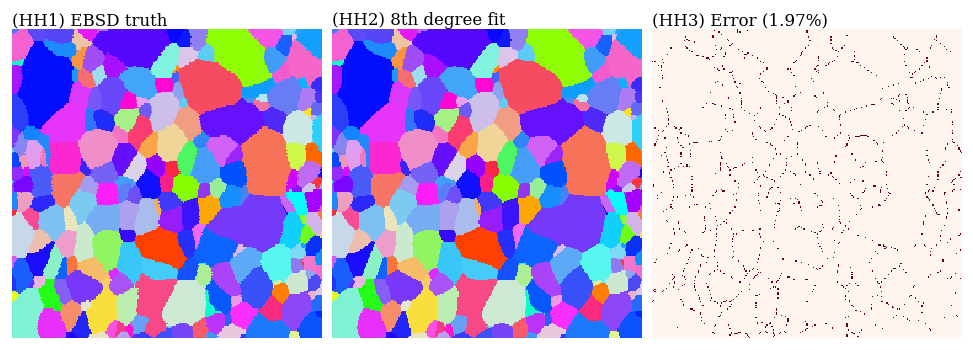

In [12]:
Path("figures").mkdir(exist_ok=True)

for j, (cfg, out) in enumerate(zip(configs, outs)):
    G_truth, G_recon, G_err, pe = grids_and_error(out, cmap_grains)
    deg  = out["ho"]
    tag  = cfg["tag"]
    heur = cfg["heuristic_guess"]

    fig, ax = plt.subplots(1, 3, figsize=(8.0, 3.6), constrained_layout=True)

    ax[0].imshow(G_truth, origin="lower", interpolation="nearest",
                 cmap=cmap_grains, vmin=0, vmax=N_grains - 1)
    ax[0].set_title(f"({tag}1) EBSD truth", loc="left", pad=3)

    ax[1].imshow(G_recon, origin="lower", interpolation="nearest",
                 cmap=cmap_grains, vmin=0, vmax=N_grains - 1)
    heur_str = ""#", heuristic init" if heur else ""
    ax[1].set_title(f"({tag}2) {ordinal(deg)} degree fit{heur_str}", loc="left", pad=3)

    ax[2].imshow(G_err, origin="lower", interpolation="nearest",
                 cmap="Reds", vmin=0, vmax=1)
    ax[2].set_title(f"({tag}3) Error ({100 * pe:.2f}%)", loc="left", pad=3)

    for a in ax:
        a.set_aspect("equal")
        a.set_axis_off()

    fig.savefig(f"figures/ebsd_small_{j}.pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()

## Summary table

In [9]:
print(
    f"{'tag':<4}  {'N':>4}  {'pixels':>8}  {'ho':>3}  {'K':>4}  "
    f"{'params':>8}  {'compress':>9}  {'heur':>5}  {'max_iter':>8}  "
    f"{'fit(s)':>8}  {'pixel err':>9}"
)
print("-" * 101)
for cfg, out in zip(configs, outs):
    _, _, _, pe = grids_and_error(out, cmap_grains)
    N = out["N"]
    M = out["Y"].shape[0]
    D = out["Y"].shape[1]
    K = math.comb(D + out["ho"], out["ho"])
    params   = N * K
    compress = params / (M + D * M)   # theta.numel() / (I.numel() + Y.numel())
    print(
        f"{cfg['tag']:<4}  "
        f"{N:>4}  "
        f"{M:>8}  "
        f"{out['ho']:>3}  "
        f"{K:>4}  "
        f"{params:>8}  "
        f"{compress:>9.4f}  "
        f"{str(cfg['heuristic_guess']):>5}  "
        f"{out['max_iter']:>8}  "
        f"{out['fit_time']:>8.2f}  "
        f"{100 * pe:>8.3f}%"
    )

tag      N    pixels   ho     K    params   compress   heur  max_iter    fit(s)  pixel err
-----------------------------------------------------------------------------------------------------
A      245     63252    1     3       735     0.0039  False      1000     25.94     8.545%
B      245     63252    2     6      1470     0.0077  False      1000     28.50     3.945%
C      245     63252    3    10      2450     0.0129  False      1000     33.59     2.909%
D      245     63252    4    15      3675     0.0194  False      1000     40.69     2.501%
E      245     63252    5    21      5145     0.0271  False      1000     47.43     2.351%
F      245     63252    6    28      6860     0.0362  False      1000     55.09     2.202%
G      245     63252    7    36      8820     0.0465  False      1000     62.90     2.058%
H      245     63252    8    45     11025     0.0581  False      1000     63.08     1.962%
AA     245     63252    1     3       735     0.0039   True      1000     25.36

## Saving the data to reproduce the figures

Results are pickled as two files:

- `results/ebsd_configs.pkl` — the list of configuration dictionaries.
- `results/ebsd_outs.pkl` — the list of CPU-only result dictionaries.

Every tensor in `outs` lives on CPU, so the pickle can be loaded on any
machine without a CUDA runtime.

In [10]:
Path("results").mkdir(exist_ok=True)

with open("results/ebsd_small_configs.pkl", "wb") as f:
    pickle.dump(configs, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("results/ebsd_small_outs.pkl", "wb") as f:
    pickle.dump(outs, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Wrote results/ebsd_small_configs.pkl and results/ebsd_small_outs.pkl")

Wrote results/ebsd_small_configs.pkl and results/ebsd_small_outs.pkl


## Reload and re-plot from pickle

Reload the pickled results and regenerate the figures without saving,
to confirm the CPU-only arrays are fully self-contained.
Note: `cmap_grains` and `N_grains` must be available (re-run the data
loading cell if starting fresh from pickle).

Reloaded 16 configurations and 16 results.


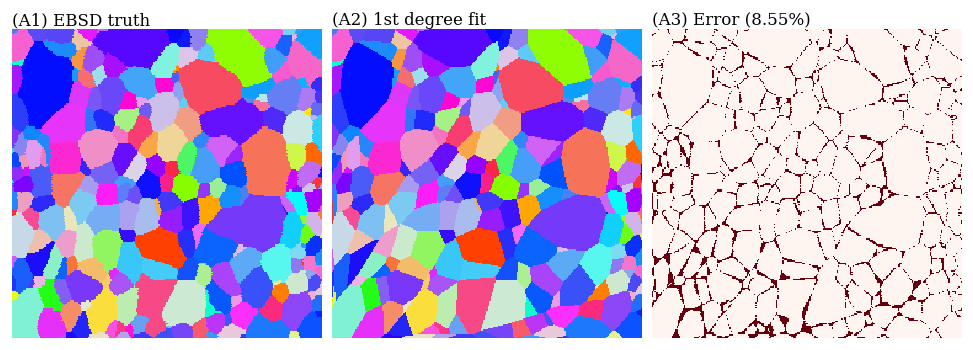

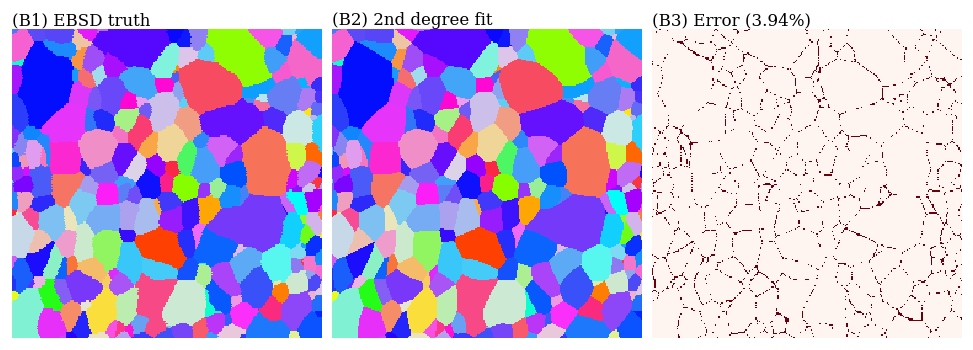

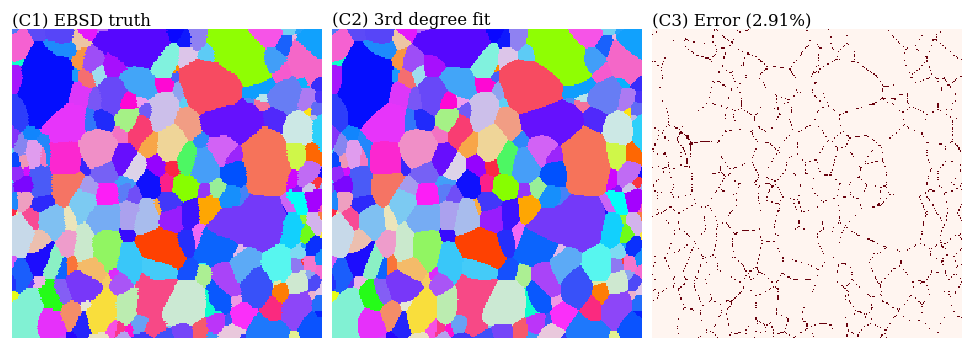

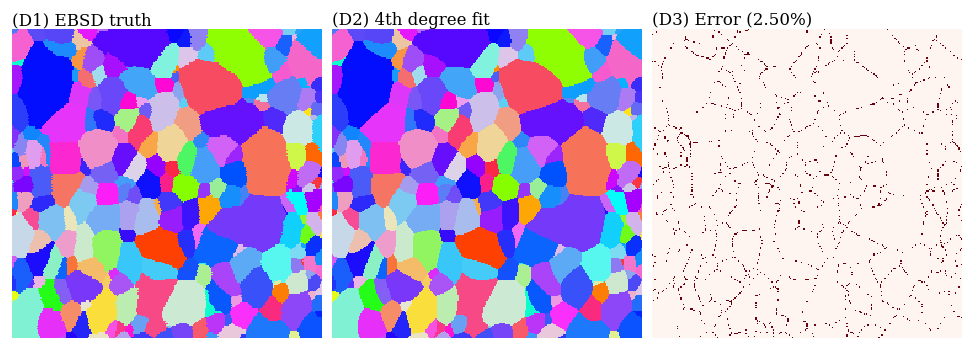

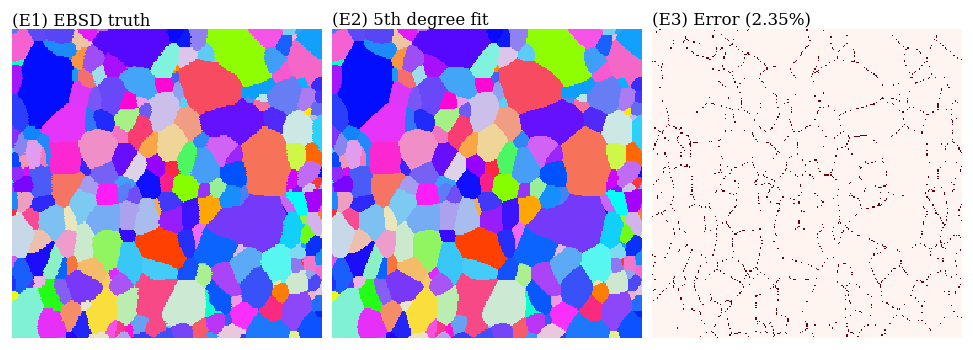

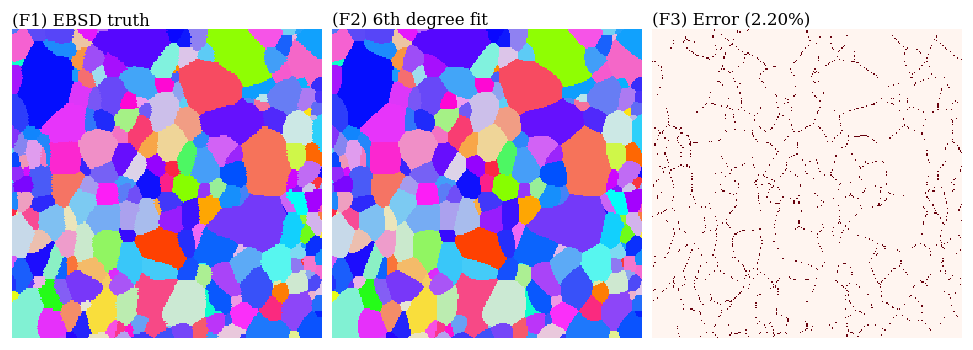

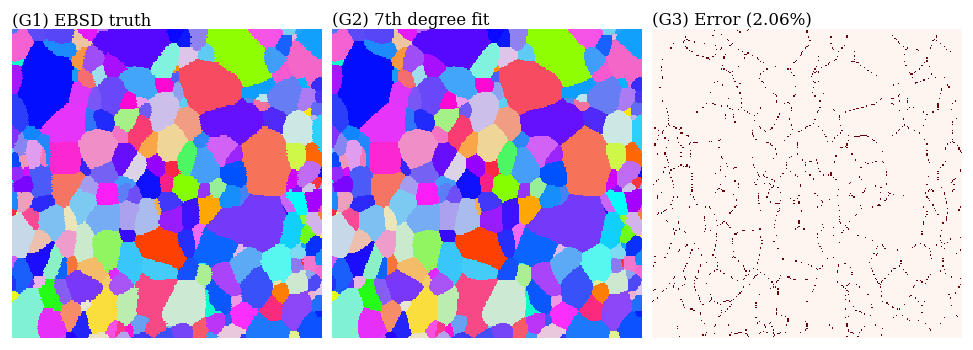

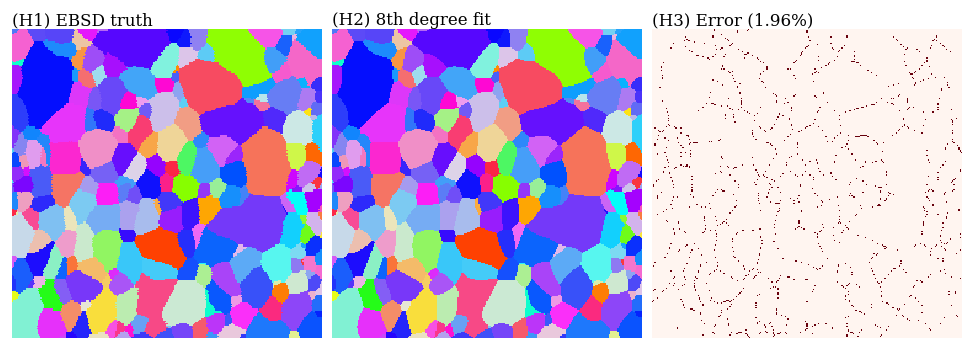

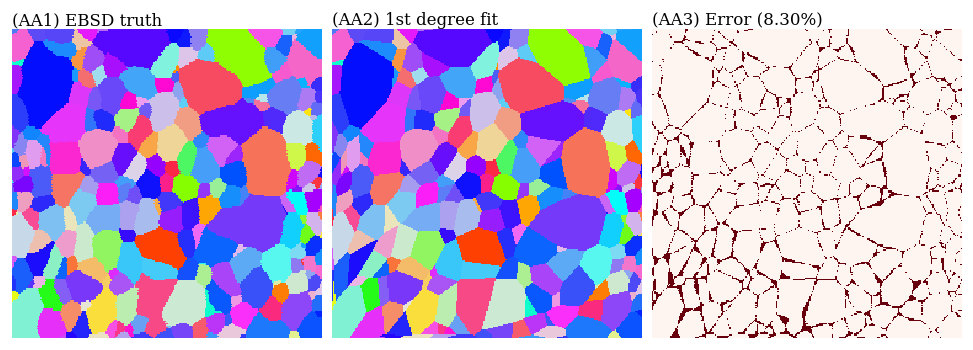

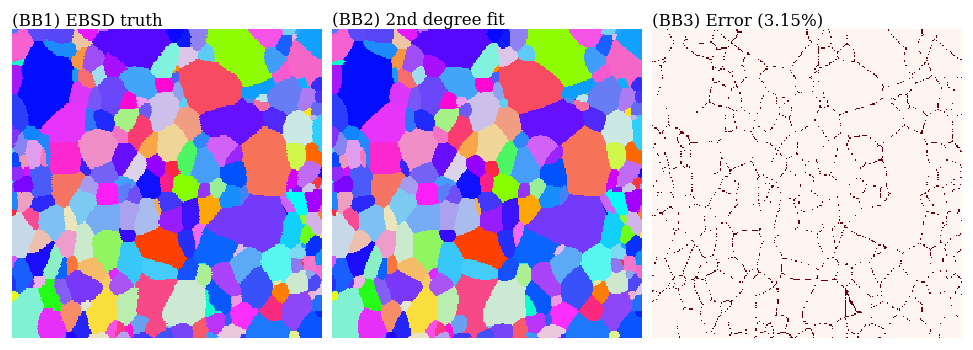

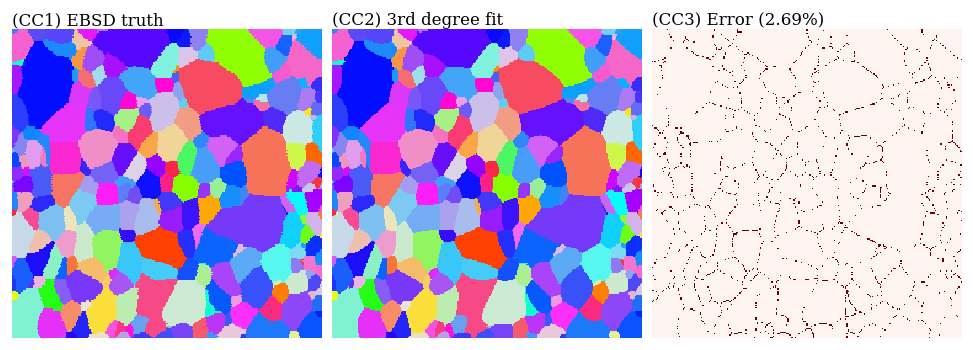

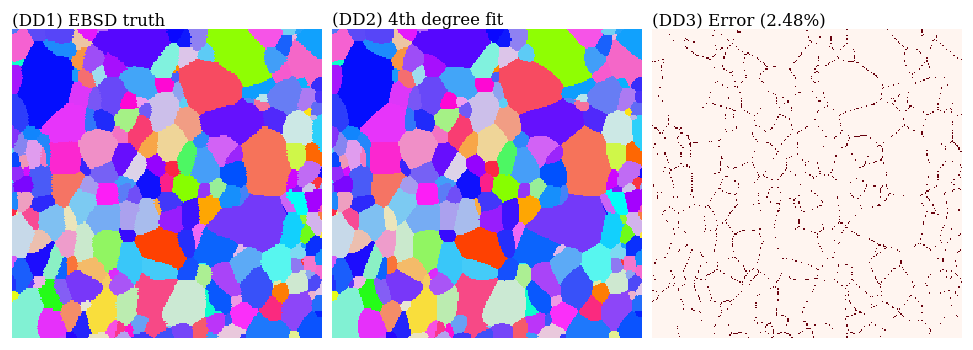

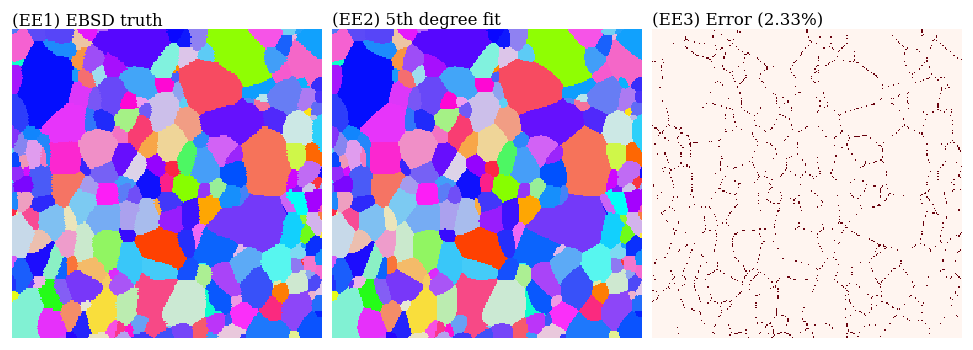

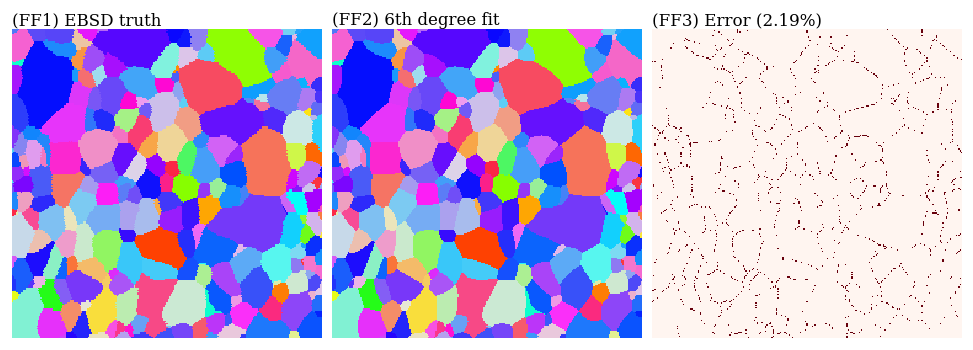

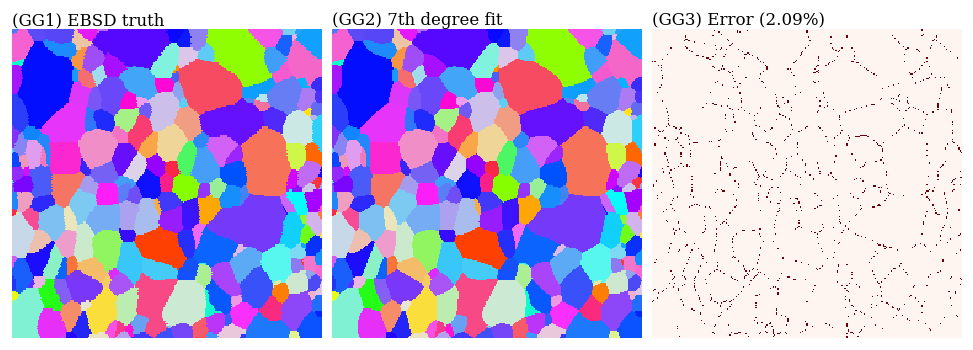

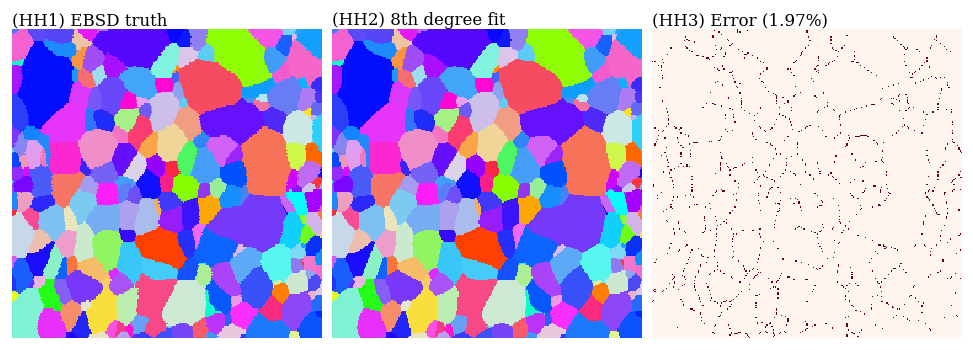

In [13]:
with open("results/ebsd_small_configs.pkl", "rb") as f:
    configs_loaded = pickle.load(f)

with open("results/ebsd_small_outs.pkl", "rb") as f:
    outs_loaded = pickle.load(f)

print(f"Reloaded {len(configs_loaded)} configurations and {len(outs_loaded)} results.")

for j, (cfg, out) in enumerate(zip(configs_loaded, outs_loaded)):
    G_truth, G_recon, G_err, pe = grids_and_error(out, cmap_grains)
    deg  = out["ho"]
    tag  = cfg["tag"]
    heur = cfg["heuristic_guess"]

    fig, ax = plt.subplots(1, 3, figsize=(8.0, 3.6), constrained_layout=True)

    ax[0].imshow(G_truth, origin="lower", interpolation="nearest",
                 cmap=cmap_grains, vmin=0, vmax=N_grains - 1)
    ax[0].set_title(f"({tag}1) EBSD truth", loc="left", pad=3)

    ax[1].imshow(G_recon, origin="lower", interpolation="nearest",
                 cmap=cmap_grains, vmin=0, vmax=N_grains - 1)
    heur_str = ""#", heuristic init" if heur else ""
    ax[1].set_title(f"({tag}2) {ordinal(deg)} degree fit{heur_str}", loc="left", pad=3)

    ax[2].imshow(G_err, origin="lower", interpolation="nearest",
                 cmap="Reds", vmin=0, vmax=1)
    ax[2].set_title(f"({tag}3) Error ({100 * pe:.2f}%)", loc="left", pad=3)

    for a in ax:
        a.set_aspect("equal")
        a.set_axis_off()

    plt.show()